In [1]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tabulate import tabulate
import time
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# 1 sekundowe pliki

## 13 cech

In [2]:
train_data = pd.read_csv("Sounds_1_seconds/mfcc_1_sec/train_13_mfcc_features_with_labels_1sec.csv")   
test_data = pd.read_csv("Sounds_1_seconds/mfcc_1_sec/test_13_mfcc_features_with_labels_1sec.csv")     

X_train = train_data.drop(['Encoded_label'], axis=1)  
y_train = train_data['Encoded_label']  

X_test = test_data.drop(['Encoded_label'], axis=1)  
y_test = test_data['Encoded_label']  

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
classifiers = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB()
}
alpha_values = [0.001, 0.01, 0.1, 1.0, 10, 100]


results = []

for clf_name, clf in classifiers.items():
    if clf_name in ['MultinomialNB', 'BernoulliNB']:
        for alpha in alpha_values:
            clf.set_params(alpha=alpha)
            start_time = time.time()
            clf.fit(X_train_scaled, y_train)
            training_time = time.time() - start_time
            
            y_pred = clf.predict(X_test_scaled)
            results.append({
                'Classifier': clf_name,
                'Parameters': f'alpha={alpha}',
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                'Recall': recall_score(y_test, y_pred, average='weighted'),
                'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                'Training Time (s)': training_time
            })
    else:
        start_time = time.time()
        clf.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        y_pred = clf.predict(X_test)
        results.append({
            'Classifier': clf_name,
            'Parameters': 'default',
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='weighted'),
            'Recall': recall_score(y_test, y_pred, average='weighted'),
            'F1 Score': f1_score(y_test, y_pred, average='weighted'),
            'Training Time (s)': training_time
        })


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
best_models = {metric: max(results, key=lambda x: x[metric]) for metric in metrics}
best_models['Training Time'] = min(results, key=lambda x: x['Training Time (s)'])

all_models_table = [
    [result['Classifier'], result['Parameters'], result['Accuracy'], result['Precision'], 
     result['Recall'], result['F1 Score'], result['Training Time (s)']]
    for result in results
]

best_models_table = [
    [metric, 
     best_models[metric]['Classifier'], 
     best_models[metric]['Parameters'], 
     best_models[metric]['Accuracy'], 
     best_models[metric]['Precision'], 
     best_models[metric]['Recall'], 
     best_models[metric]['F1 Score'], 
     best_models[metric]['Training Time (s)']]
    for metric in metrics + ['Training Time']
]

print("Best Models for Each Metric:")
print(tabulate(best_models_table, headers=[
    "Metric", "Best Classifier", "Parameters", "Accuracy", "Precision", "Recall", "F1 Score", "Training Time (s)"
], tablefmt="fancy_grid"))



Best Models for Each Metric:
╒═══════════════╤═══════════════════╤══════════════╤════════════╤═════════════╤══════════╤════════════╤═════════════════════╕
│ Metric        │ Best Classifier   │ Parameters   │   Accuracy │   Precision │   Recall │   F1 Score │   Training Time (s) │
╞═══════════════╪═══════════════════╪══════════════╪════════════╪═════════════╪══════════╪════════════╪═════════════════════╡
│ Accuracy      │ GaussianNB        │ default      │   0.764157 │    0.750963 │ 0.764157 │   0.746898 │          0.0190115  │
├───────────────┼───────────────────┼──────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────────┤
│ Precision     │ MultinomialNB     │ alpha=1.0    │   0.759789 │    0.753687 │ 0.759789 │   0.75241  │          0.00600076 │
├───────────────┼───────────────────┼──────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────────┤
│ Recall        │ GaussianNB        │ default      │   0.764157 │    0.750963 │ 0.764157 

 GaussianNB :
  Dokładność (Accuracy): 0.7661
  Precyzja (Precision): 0.7618
  Recall: 0.7661
  F1 Score: 0.7632
  Czas treningu: 0.0080 sekund

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.78      0.75      1660
           1       0.59      0.53      0.55      1660
           2       0.79      0.82      0.81      1660
           3       0.94      0.94      0.94      1660

    accuracy                           0.77      6640
   macro avg       0.76      0.77      0.76      6640
weighted avg       0.76      0.77      0.76      6640



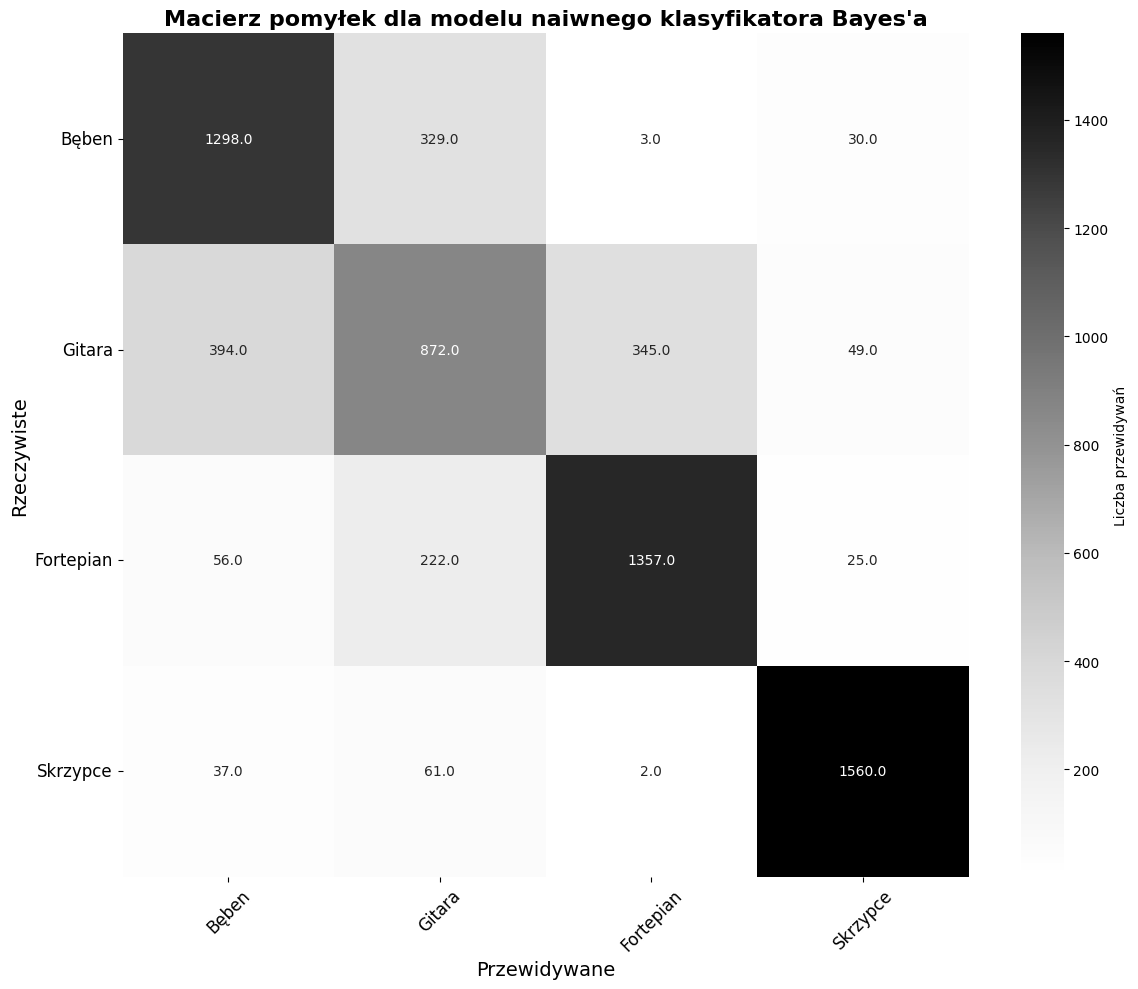

In [4]:
model = GaussianNB()

start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time


unique_labels = y_test.unique()
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


print(" GaussianNB :")
print(f"  Dokładność (Accuracy): {accuracy:.4f}")
print(f"  Precyzja (Precision): {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  Czas treningu: {training_time:.4f} sekund")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(label) for label in sorted(unique_labels)]))


label_mapping = {
    0: "Bęben",
    1: "Gitara",
    2: "Fortepian",
    3: "Skrzypce"
}

# Posortowane unikalne etykiety
sorted_labels = np.sort(unique_labels)

# Zamiana etykiet liczbowych na nazwy klas
mapped_labels = [label_mapping[label] for label in sorted_labels]

# Tworzenie macierzy pomyłek
conf_matrix = confusion_matrix(y_test, y_pred, labels=sorted_labels)

# Wizualizacja macierzy pomyłek
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt=".1f", cmap="Greys", 
            xticklabels=mapped_labels, yticklabels=mapped_labels, cbar_kws={'label': 'Liczba przewidywań'})

plt.xlabel("Przewidywane", fontsize=14)
plt.ylabel("Rzeczywiste", fontsize=14)
plt.title("Macierz pomyłek dla modelu naiwnego klasyfikatora Bayes'a", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()


## 30 cech

In [50]:
train_data = pd.read_csv("Sounds_1_seconds/mfcc_1_sec/train_30_mfcc_features_with_labels_1sec.csv")   
test_data = pd.read_csv("Sounds_1_seconds/mfcc_1_sec/test_30_mfcc_features_with_labels_1sec.csv")     

X_train = train_data.drop(['Encoded_label'], axis=1)  
y_train = train_data['Encoded_label']  

X_test = test_data.drop(['Encoded_label'], axis=1)  
y_test = test_data['Encoded_label']  

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
classifiers = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB()
}
alpha_values = [0.001, 0.01, 0.1, 1.0, 10, 100]


results = []

for clf_name, clf in classifiers.items():
    if clf_name in ['MultinomialNB', 'BernoulliNB']:
        for alpha in alpha_values:
            clf.set_params(alpha=alpha)
            start_time = time.time()
            clf.fit(X_train_scaled, y_train)
            training_time = time.time() - start_time
            
            y_pred = clf.predict(X_test_scaled)
            results.append({
                'Classifier': clf_name,
                'Parameters': f'alpha={alpha}',
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                'Recall': recall_score(y_test, y_pred, average='weighted'),
                'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                'Training Time (s)': training_time
            })
    else:
        start_time = time.time()
        clf.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        y_pred = clf.predict(X_test)
        results.append({
            'Classifier': clf_name,
            'Parameters': 'default',
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_test, y_pred, average='weighted'),
            'F1 Score': f1_score(y_test, y_pred, average='weighted'),
            'Training Time (s)': training_time
        })


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
best_models = {metric: max(results, key=lambda x: x[metric]) for metric in metrics}
best_models['Training Time'] = min(results, key=lambda x: x['Training Time (s)'])

all_models_table = [
    [result['Classifier'], result['Parameters'], result['Accuracy'], result['Precision'], 
     result['Recall'], result['F1 Score'], result['Training Time (s)']]
    for result in results
]

best_models_table = [
    [metric, 
     best_models[metric]['Classifier'], 
     best_models[metric]['Parameters'], 
     best_models[metric]['Accuracy'], 
     best_models[metric]['Precision'], 
     best_models[metric]['Recall'], 
     best_models[metric]['F1 Score'], 
     best_models[metric]['Training Time (s)']]
    for metric in metrics + ['Training Time']
]

print("Best Models for Each Metric:")
print(tabulate(best_models_table, headers=[
    "Metric", "Best Classifier", "Parameters", "Accuracy", "Precision", "Recall", "F1 Score", "Training Time (s)"
], tablefmt="fancy_grid"))

Best Models for Each Metric:
╒═══════════════╤═══════════════════╤══════════════╤════════════╤═════════════╤══════════╤════════════╤═════════════════════╕
│ Metric        │ Best Classifier   │ Parameters   │   Accuracy │   Precision │   Recall │   F1 Score │   Training Time (s) │
╞═══════════════╪═══════════════════╪══════════════╪════════════╪═════════════╪══════════╪════════════╪═════════════════════╡
│ Accuracy      │ GaussianNB        │ default      │   0.764157 │    0.750963 │ 0.764157 │   0.746898 │          0.021014   │
├───────────────┼───────────────────┼──────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────────┤
│ Precision     │ MultinomialNB     │ alpha=1.0    │   0.759789 │    0.753687 │ 0.759789 │   0.75241  │          0.00598741 │
├───────────────┼───────────────────┼──────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────────┤
│ Recall        │ GaussianNB        │ default      │   0.764157 │    0.750963 │ 0.764157 

 GaussianNB :
  Dokładność (Accuracy): 0.7642
  Precyzja (Precision): 0.7510
  Recall: 0.7642
  F1 Score: 0.7469
  Czas treningu: 0.0190 sekund

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.90      0.80      1660
           1       0.62      0.38      0.47      1660
           2       0.75      0.81      0.78      1660
           3       0.91      0.97      0.94      1660

    accuracy                           0.76      6640
   macro avg       0.75      0.76      0.75      6640
weighted avg       0.75      0.76      0.75      6640



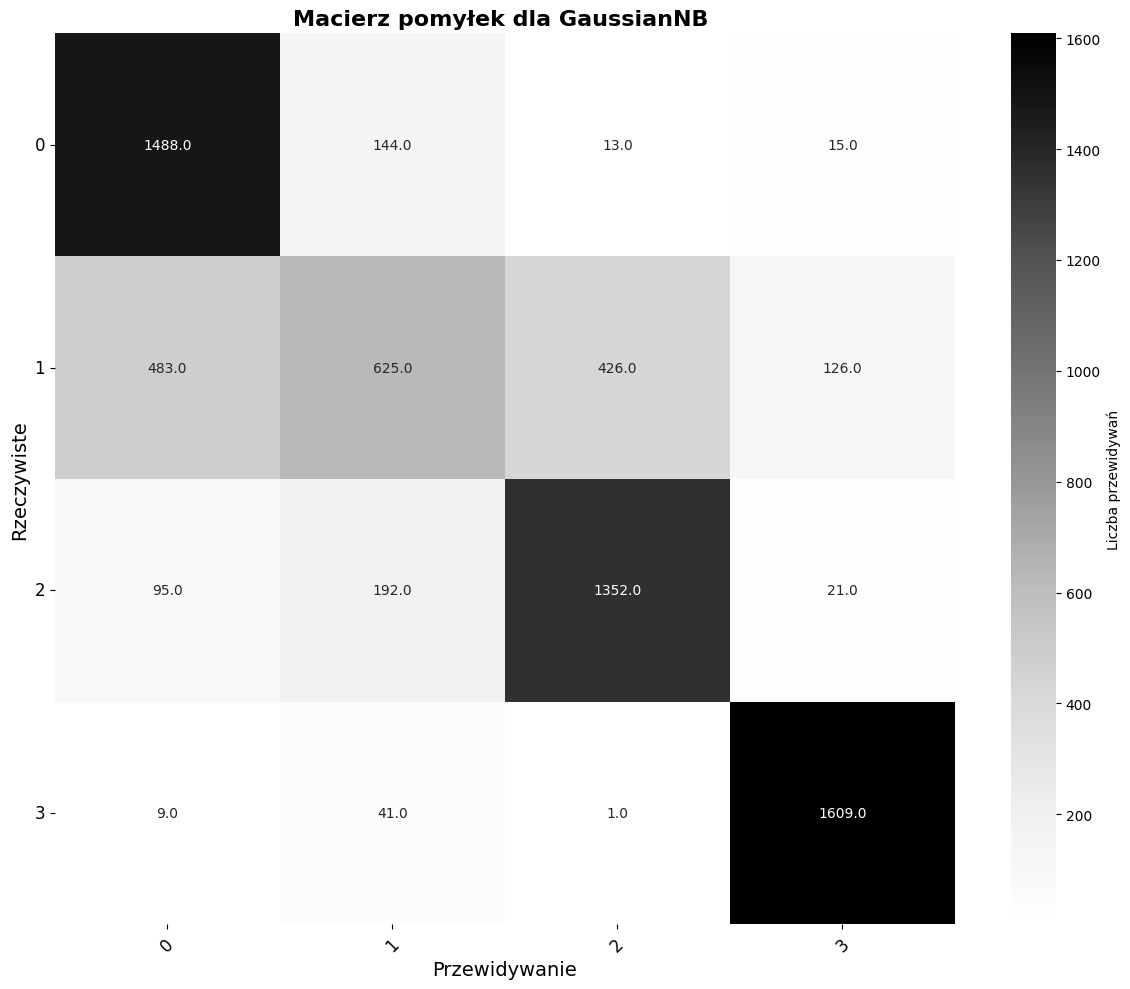

In [53]:
model =  GaussianNB()

start_time = time.time()
model.fit(X_train_scaled, y_train)
training_time = time.time() - start_time


unique_labels = y_test.unique()
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


print(" GaussianNB :")
print(f"  Dokładność (Accuracy): {accuracy:.4f}")
print(f"  Precyzja (Precision): {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  Czas treningu: {training_time:.4f} sekund")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(label) for label in sorted(unique_labels)]))


sorted_labels = np.sort(unique_labels)
conf_matrix = confusion_matrix(y_test, y_pred, labels=sorted_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt=".1f", cmap="Greys", 
            xticklabels=sorted_labels, yticklabels=sorted_labels, cbar_kws={'label': 'Liczba przewidywań'})

plt.xlabel("Przewidywanie", fontsize=14)
plt.ylabel("Rzeczywiste", fontsize=14)
plt.title("Macierz pomyłek dla GaussianNB ", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()

## 50 cech

In [55]:
train_data = pd.read_csv("Sounds_1_seconds/mfcc_1_sec/train_50_mfcc_features_with_labels_1sec.csv")   
test_data = pd.read_csv("Sounds_1_seconds/mfcc_1_sec/test_50_mfcc_features_with_labels_1sec.csv")     

X_train = train_data.drop(['Encoded_label'], axis=1)  
y_train = train_data['Encoded_label']  

X_test = test_data.drop(['Encoded_label'], axis=1)  
y_test = test_data['Encoded_label']  

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
classifiers = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB()
}
alpha_values = [0.001, 0.01, 0.1, 1.0, 10, 100]


results = []

for clf_name, clf in classifiers.items():
    if clf_name in ['MultinomialNB', 'BernoulliNB']:
        for alpha in alpha_values:
            clf.set_params(alpha=alpha)
            start_time = time.time()
            clf.fit(X_train_scaled, y_train)
            training_time = time.time() - start_time
            
            y_pred = clf.predict(X_test_scaled)
            results.append({
                'Classifier': clf_name,
                'Parameters': f'alpha={alpha}',
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                'Recall': recall_score(y_test, y_pred, average='weighted'),
                'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                'Training Time (s)': training_time
            })
    else:
        start_time = time.time()
        clf.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        y_pred = clf.predict(X_test)
        results.append({
            'Classifier': clf_name,
            'Parameters': 'default',
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='weighted'),
            'Recall': recall_score(y_test, y_pred, average='weighted'),
            'F1 Score': f1_score(y_test, y_pred, average='weighted'),
            'Training Time (s)': training_time
        })


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
best_models = {metric: max(results, key=lambda x: x[metric]) for metric in metrics}
best_models['Training Time'] = min(results, key=lambda x: x['Training Time (s)'])

all_models_table = [
    [result['Classifier'], result['Parameters'], result['Accuracy'], result['Precision'], 
     result['Recall'], result['F1 Score'], result['Training Time (s)']]
    for result in results
]

best_models_table = [
    [metric, 
     best_models[metric]['Classifier'], 
     best_models[metric]['Parameters'], 
     best_models[metric]['Accuracy'], 
     best_models[metric]['Precision'], 
     best_models[metric]['Recall'], 
     best_models[metric]['F1 Score'], 
     best_models[metric]['Training Time (s)']]
    for metric in metrics + ['Training Time']
]

print("Best Models for Each Metric:")
print(tabulate(best_models_table, headers=[
    "Metric", "Best Classifier", "Parameters", "Accuracy", "Precision", "Recall", "F1 Score", "Training Time (s)"
], tablefmt="fancy_grid"))

Best Models for Each Metric:
╒═══════════════╤═══════════════════╤══════════════╤════════════╤═════════════╤══════════╤════════════╤═════════════════════╕
│ Metric        │ Best Classifier   │ Parameters   │   Accuracy │   Precision │   Recall │   F1 Score │   Training Time (s) │
╞═══════════════╪═══════════════════╪══════════════╪════════════╪═════════════╪══════════╪════════════╪═════════════════════╡
│ Accuracy      │ GaussianNB        │ default      │   0.77756  │    0.767107 │ 0.77756  │   0.760509 │          0.0290034  │
├───────────────┼───────────────────┼──────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────────┤
│ Precision     │ GaussianNB        │ default      │   0.77756  │    0.767107 │ 0.77756  │   0.760509 │          0.0290034  │
├───────────────┼───────────────────┼──────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────────┤
│ Recall        │ GaussianNB        │ default      │   0.77756  │    0.767107 │ 0.77756  

 GaussianNB :
  Dokładność (Accuracy): 0.7776
  Precyzja (Precision): 0.7671
  Recall: 0.7776
  F1 Score: 0.7605
  Czas treningu: 0.0300 sekund

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.94      0.83      1660
           1       0.67      0.40      0.50      1660
           2       0.76      0.80      0.78      1660
           3       0.91      0.97      0.94      1660

    accuracy                           0.78      6640
   macro avg       0.77      0.78      0.76      6640
weighted avg       0.77      0.78      0.76      6640



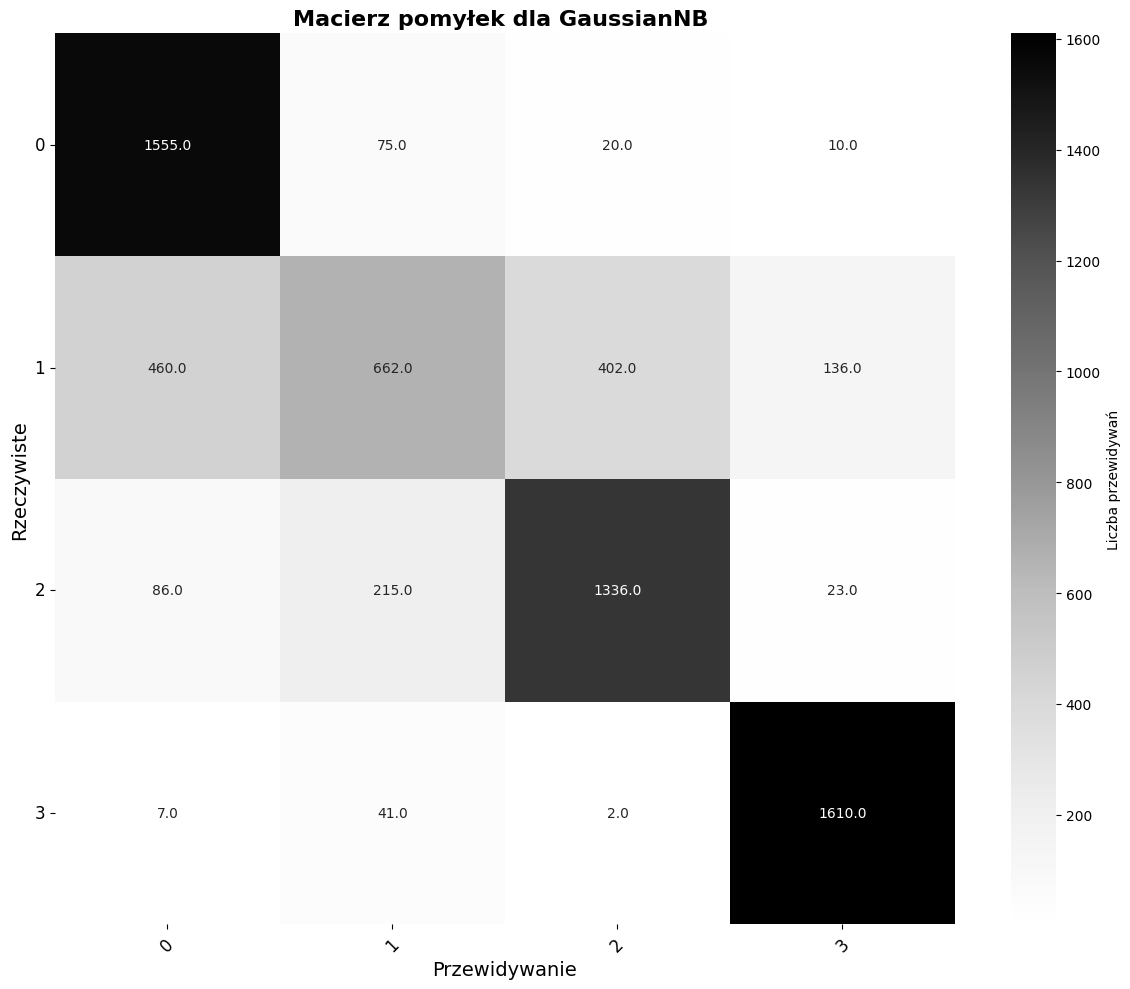

In [58]:
model =  GaussianNB()

start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time


unique_labels = y_test.unique()
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


print(" GaussianNB :")
print(f"  Dokładność (Accuracy): {accuracy:.4f}")
print(f"  Precyzja (Precision): {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  Czas treningu: {training_time:.4f} sekund")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(label) for label in sorted(unique_labels)]))


sorted_labels = np.sort(unique_labels)
conf_matrix = confusion_matrix(y_test, y_pred, labels=sorted_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt=".1f", cmap="Greys", 
            xticklabels=sorted_labels, yticklabels=sorted_labels, cbar_kws={'label': 'Liczba przewidywań'})

plt.xlabel("Przewidywanie", fontsize=14)
plt.ylabel("Rzeczywiste", fontsize=14)
plt.title("Macierz pomyłek dla GaussianNB ", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()

# 3 sekundowe pliki

In [59]:
train_data = pd.read_csv("Sounds_3_seconds/mfcc_3_sec/train_13_mfcc_features_with_labels_3sec.csv")   
test_data = pd.read_csv("Sounds_3_seconds/mfcc_3_sec/test_13_mfcc_features_with_labels_3sec.csv")     

X_train = train_data.drop(['Encoded_label'], axis=1)  
y_train = train_data['Encoded_label']  

X_test = test_data.drop(['Encoded_label'], axis=1)  
y_test = test_data['Encoded_label']  

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
classifiers = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB()
}
alpha_values = [0.001, 0.01, 0.1, 1.0, 10, 100]


results = []

for clf_name, clf in classifiers.items():
    if clf_name in ['MultinomialNB', 'BernoulliNB']:
        for alpha in alpha_values:
            clf.set_params(alpha=alpha)
            start_time = time.time()
            clf.fit(X_train_scaled, y_train)
            training_time = time.time() - start_time
            
            y_pred = clf.predict(X_test_scaled)
            results.append({
                'Classifier': clf_name,
                'Parameters': f'alpha={alpha}',
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                'Recall': recall_score(y_test, y_pred, average='weighted'),
                'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                'Training Time (s)': training_time
            })
    else:
        start_time = time.time()
        clf.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        y_pred = clf.predict(X_test)
        results.append({
            'Classifier': clf_name,
            'Parameters': 'default',
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_test, y_pred, average='weighted'),
            'F1 Score': f1_score(y_test, y_pred, average='weighted'),
            'Training Time (s)': training_time
        })


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
best_models = {metric: max(results, key=lambda x: x[metric]) for metric in metrics}
best_models['Training Time'] = min(results, key=lambda x: x['Training Time (s)'])

all_models_table = [
    [result['Classifier'], result['Parameters'], result['Accuracy'], result['Precision'], 
     result['Recall'], result['F1 Score'], result['Training Time (s)']]
    for result in results
]

best_models_table = [
    [metric, 
     best_models[metric]['Classifier'], 
     best_models[metric]['Parameters'], 
     best_models[metric]['Accuracy'], 
     best_models[metric]['Precision'], 
     best_models[metric]['Recall'], 
     best_models[metric]['F1 Score'], 
     best_models[metric]['Training Time (s)']]
    for metric in metrics + ['Training Time']
]


print("Best Models for Each Metric:")
print(tabulate(best_models_table, headers=[
    "Metric", "Best Classifier", "Parameters", "Accuracy", "Precision", "Recall", "F1 Score", "Training Time (s)"
], tablefmt="fancy_grid"))

Best Models for Each Metric:
╒═══════════════╤═══════════════════╤══════════════╤════════════╤═════════════╤══════════╤════════════╤═════════════════════╕
│ Metric        │ Best Classifier   │ Parameters   │   Accuracy │   Precision │   Recall │   F1 Score │   Training Time (s) │
╞═══════════════╪═══════════════════╪══════════════╪════════════╪═════════════╪══════════╪════════════╪═════════════════════╡
│ Accuracy      │ GaussianNB        │ default      │   0.743534 │    0.740042 │ 0.743534 │   0.741591 │          0.00500011 │
├───────────────┼───────────────────┼──────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────────┤
│ Precision     │ GaussianNB        │ default      │   0.743534 │    0.740042 │ 0.743534 │   0.741591 │          0.00500011 │
├───────────────┼───────────────────┼──────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────────┤
│ Recall        │ GaussianNB        │ default      │   0.743534 │    0.740042 │ 0.743534 

 GaussianNB :
  Dokładność (Accuracy): 0.7435
  Precyzja (Precision): 0.7400
  Recall: 0.7435
  F1 Score: 0.7416
  Czas treningu: 0.0040 sekund

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       580
           1       0.54      0.51      0.53       580
           2       0.79      0.78      0.78       580
           3       0.93      0.96      0.95       580

    accuracy                           0.74      2320
   macro avg       0.74      0.74      0.74      2320
weighted avg       0.74      0.74      0.74      2320



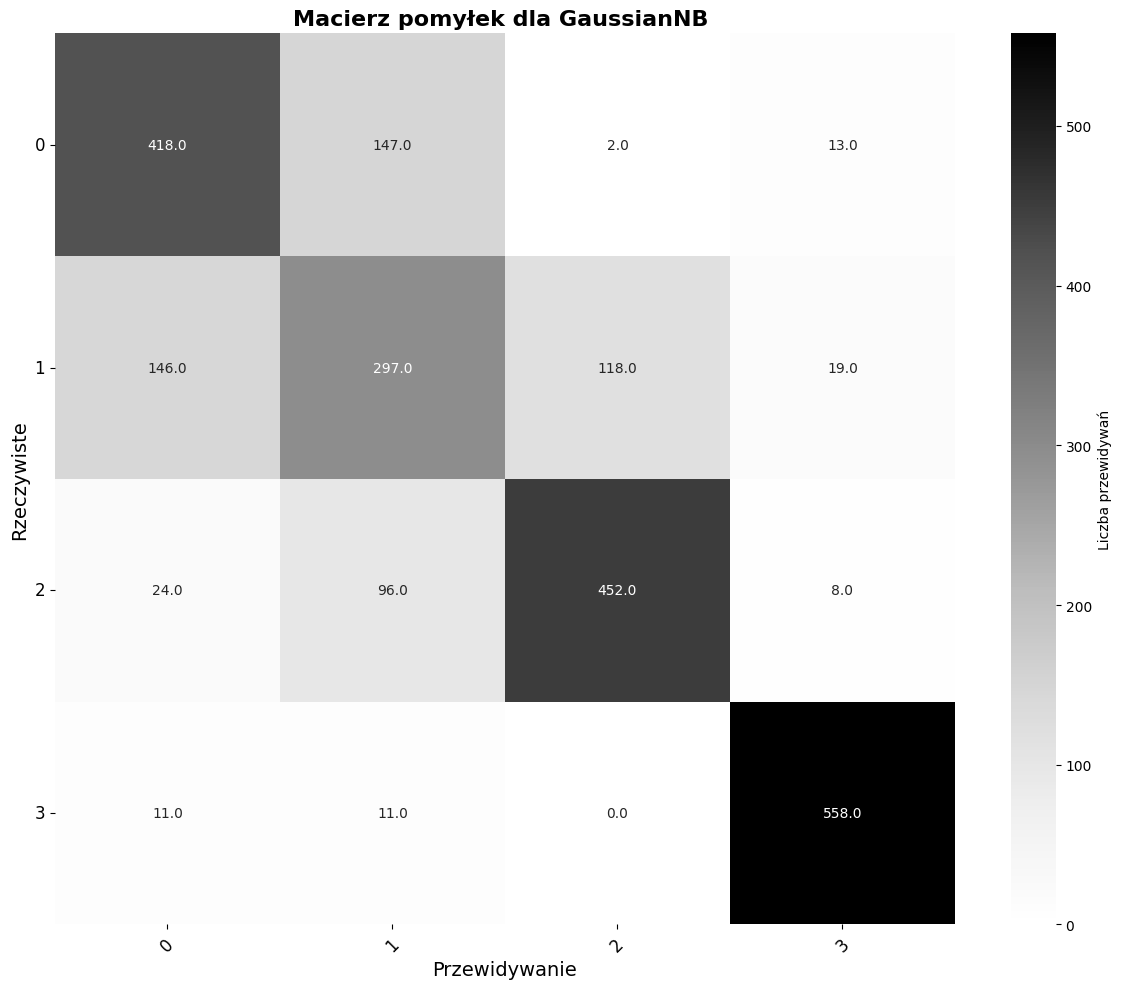

In [62]:
model =  GaussianNB()

start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time


unique_labels = y_test.unique()
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


print(" GaussianNB :")
print(f"  Dokładność (Accuracy): {accuracy:.4f}")
print(f"  Precyzja (Precision): {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  Czas treningu: {training_time:.4f} sekund")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(label) for label in sorted(unique_labels)]))


sorted_labels = np.sort(unique_labels)
conf_matrix = confusion_matrix(y_test, y_pred, labels=sorted_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt=".1f", cmap="Greys", 
            xticklabels=sorted_labels, yticklabels=sorted_labels, cbar_kws={'label': 'Liczba przewidywań'})

plt.xlabel("Przewidywanie", fontsize=14)
plt.ylabel("Rzeczywiste", fontsize=14)
plt.title("Macierz pomyłek dla GaussianNB ", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()

## 5 sekundowe pliki

In [66]:
train_data = pd.read_csv("Sounds_5_seconds/mfcc_5_sec/train_13_mfcc_features_with_labels_5sec.csv")   
test_data = pd.read_csv("Sounds_5_seconds/mfcc_5_sec/test_13_mfcc_features_with_labels_5sec.csv")     

X_train = train_data.drop(['Encoded_label'], axis=1)  
y_train = train_data['Encoded_label']  

X_test = test_data.drop(['Encoded_label'], axis=1)  
y_test = test_data['Encoded_label']  

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
classifiers = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB()
}
alpha_values = [0.001, 0.01, 0.1, 1.0, 10, 100]


results = []

for clf_name, clf in classifiers.items():
    if clf_name in ['MultinomialNB', 'BernoulliNB']:
        for alpha in alpha_values:
            clf.set_params(alpha=alpha)
            start_time = time.time()
            clf.fit(X_train_scaled, y_train)
            training_time = time.time() - start_time
            
            y_pred = clf.predict(X_test_scaled)
            results.append({
                'Classifier': clf_name,
                'Parameters': f'alpha={alpha}',
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                'Recall': recall_score(y_test, y_pred, average='weighted'),
                'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                'Training Time (s)': training_time
            })
    else:
        start_time = time.time()
        clf.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        y_pred = clf.predict(X_test)
        results.append({
            'Classifier': clf_name,
            'Parameters': 'default',
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_test, y_pred, average='weighted'),
            'F1 Score': f1_score(y_test, y_pred, average='weighted'),
            'Training Time (s)': training_time
        })


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
best_models = {metric: max(results, key=lambda x: x[metric]) for metric in metrics}
best_models['Training Time'] = min(results, key=lambda x: x['Training Time (s)'])

all_models_table = [
    [result['Classifier'], result['Parameters'], result['Accuracy'], result['Precision'], 
     result['Recall'], result['F1 Score'], result['Training Time (s)']]
    for result in results
]

best_models_table = [
    [metric, 
     best_models[metric]['Classifier'], 
     best_models[metric]['Parameters'], 
     best_models[metric]['Accuracy'], 
     best_models[metric]['Precision'], 
     best_models[metric]['Recall'], 
     best_models[metric]['F1 Score'], 
     best_models[metric]['Training Time (s)']]
    for metric in metrics + ['Training Time']
]


print("Best Models for Each Metric:")
print(tabulate(best_models_table, headers=[
    "Metric", "Best Classifier", "Parameters", "Accuracy", "Precision", "Recall", "F1 Score", "Training Time (s)"
], tablefmt="fancy_grid"))

Best Models for Each Metric:
╒═══════════════╤═══════════════════╤══════════════╤════════════╤═════════════╤══════════╤════════════╤═════════════════════╕
│ Metric        │ Best Classifier   │ Parameters   │   Accuracy │   Precision │   Recall │   F1 Score │   Training Time (s) │
╞═══════════════╪═══════════════════╪══════════════╪════════════╪═════════════╪══════════╪════════════╪═════════════════════╡
│ Accuracy      │ MultinomialNB     │ alpha=100    │   0.746875 │    0.74108  │ 0.746875 │   0.73859  │         0.00100207  │
├───────────────┼───────────────────┼──────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────────┤
│ Precision     │ MultinomialNB     │ alpha=0.01   │   0.74375  │    0.743882 │ 0.74375  │   0.740797 │         0.00199842  │
├───────────────┼───────────────────┼──────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────────┤
│ Recall        │ MultinomialNB     │ alpha=100    │   0.746875 │    0.74108  │ 0.746875 

 MultinomialNB :
  Dokładność (Accuracy): 0.7469
  Precyzja (Precision): 0.7411
  Recall: 0.7469
  F1 Score: 0.7386
  Czas treningu: 0.0020 sekund

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.85      0.77       320
           1       0.58      0.43      0.49       320
           2       0.75      0.83      0.79       320
           3       0.93      0.88      0.90       320

    accuracy                           0.75      1280
   macro avg       0.74      0.75      0.74      1280
weighted avg       0.74      0.75      0.74      1280



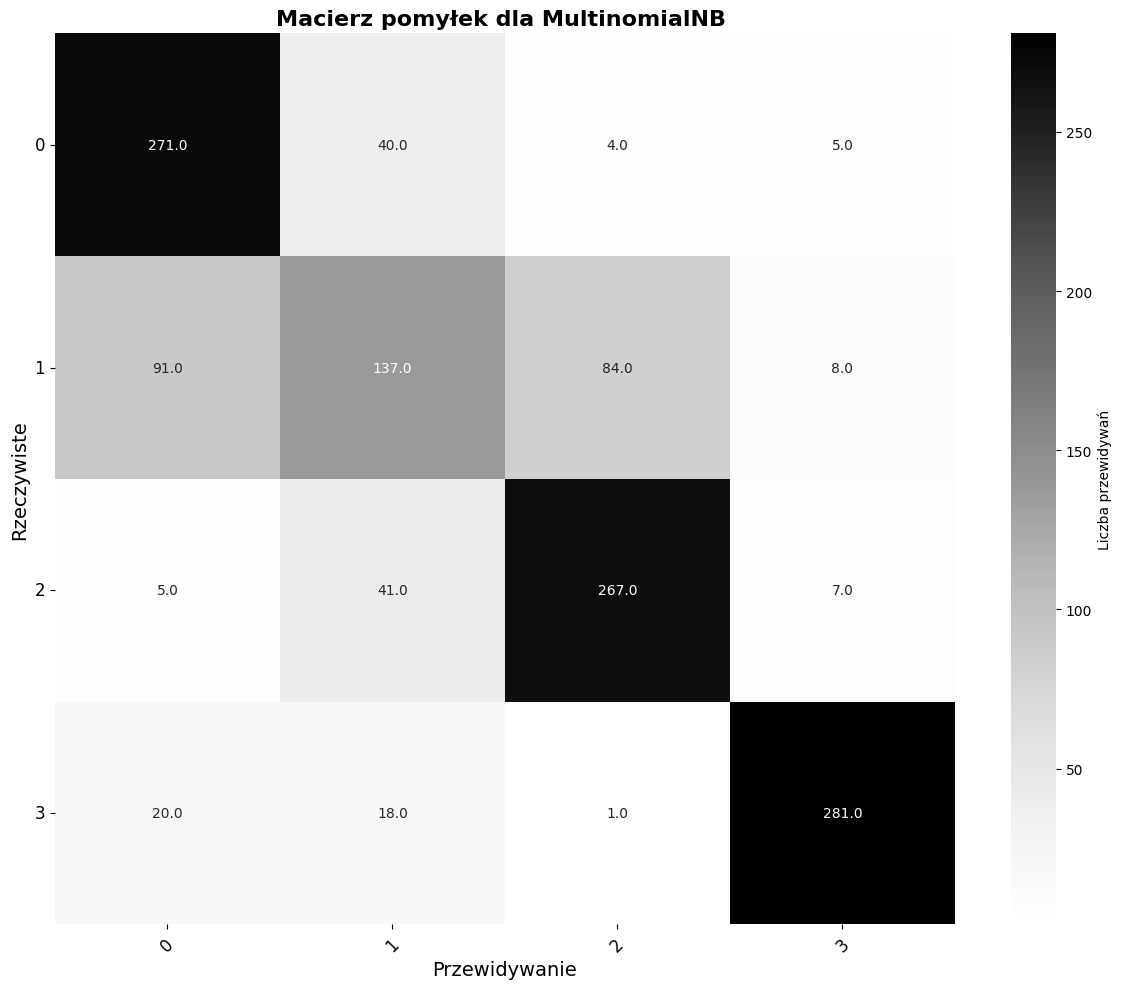

In [70]:
model =  MultinomialNB(alpha = 100)

start_time = time.time()
model.fit(X_train_scaled, y_train)
training_time = time.time() - start_time


unique_labels = y_test.unique()
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


print(" MultinomialNB :")
print(f"  Dokładność (Accuracy): {accuracy:.4f}")
print(f"  Precyzja (Precision): {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  Czas treningu: {training_time:.4f} sekund")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(label) for label in sorted(unique_labels)]))


sorted_labels = np.sort(unique_labels)
conf_matrix = confusion_matrix(y_test, y_pred, labels=sorted_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt=".1f", cmap="Greys", 
            xticklabels=sorted_labels, yticklabels=sorted_labels, cbar_kws={'label': 'Liczba przewidywań'})

plt.xlabel("Przewidywanie", fontsize=14)
plt.ylabel("Rzeczywiste", fontsize=14)
plt.title("Macierz pomyłek dla MultinomialNB ", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()